In [1]:
import pandas as pd
import matplotlib.pyplot as plt

=== EMERALDS ===
count    20000.00000
mean      9999.99760
std          0.72334
min       9996.00000
25%      10000.00000
50%      10000.00000
75%      10000.00000
max      10004.00000
Name: mid_price, dtype: float64

=== TOMATOES ===
count    20000.000000
mean      4992.758125
std         19.747055
min       4946.500000
25%       4980.000000
50%       4995.500000
75%       5006.500000
max       5036.000000
Name: mid_price, dtype: float64


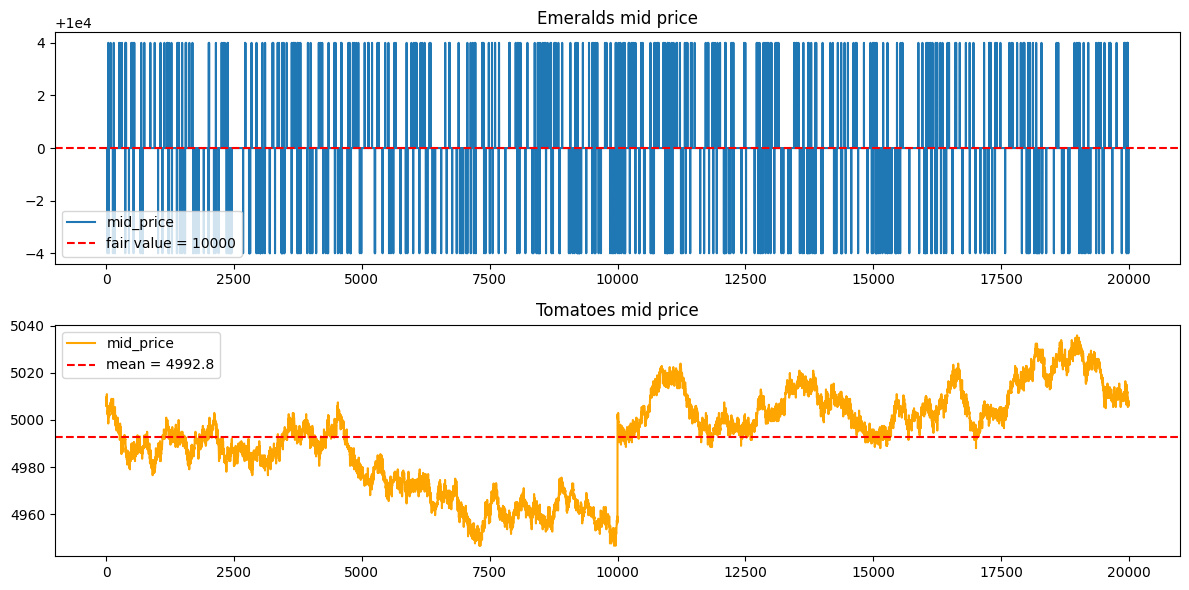

In [2]:
# Charger les deux jours
day1 = pd.read_csv("data/prices_round_0_day_-1.csv", sep=";")
day2 = pd.read_csv("data/prices_round_0_day_-2.csv", sep=";")
df = pd.concat([day1, day2])

# Séparer les deux produits
emeralds = df[df["product"] == "EMERALDS"]["mid_price"]
tomatoes = df[df["product"] == "TOMATOES"]["mid_price"]

# Stats rapides
print("=== EMERALDS ===")
print(emeralds.describe())

print("\n=== TOMATOES ===")
print(tomatoes.describe())

# Graphique comparatif
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

emeralds.reset_index(drop=True).plot(ax=ax1, title="Emeralds mid price")
ax1.axhline(10000, color="red", linestyle="--", label="fair value = 10000")
ax1.legend()

tomatoes.reset_index(drop=True).plot(ax=ax2, title="Tomatoes mid price", color="orange")
ax2.axhline(tomatoes.mean(), color="red", linestyle="--", label=f"mean = {tomatoes.mean():.1f}")
ax2.legend()

plt.tight_layout()
plt.show()

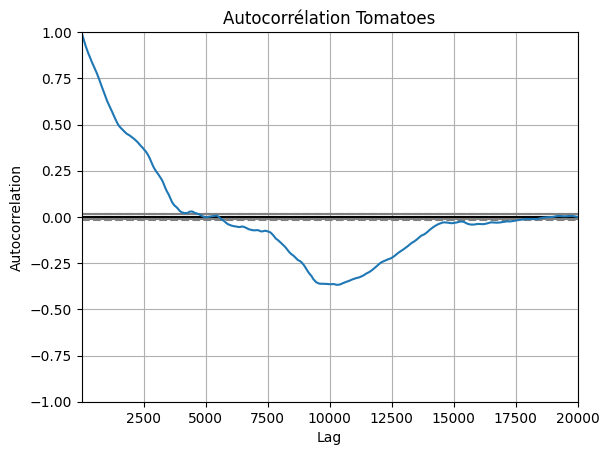

count    19999.000000
mean         0.000025
std          1.375073
min         -8.500000
25%         -0.500000
50%          0.000000
75%          0.500000
max         43.000000
Name: returns, dtype: float64

Retour moyen : 0.0000
% de hausses : 33.84%
% de baisses : 34.06%


In [3]:
tomatoes = df[df["product"] == "TOMATOES"].copy()
tomatoes = tomatoes.reset_index(drop=True)

# Autocorrélation — est-ce que le prix d'aujourd'hui prédit celui de demain ?
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(tomatoes["mid_price"])
plt.title("Autocorrélation Tomatoes")
plt.show()

# Retours tick par tick
tomatoes["returns"] = tomatoes["mid_price"].diff()
print(tomatoes["returns"].describe())
print(f"\nRetour moyen : {tomatoes['returns'].mean():.4f}")
print(f"% de hausses : {(tomatoes['returns'] > 0).mean():.2%}")
print(f"% de baisses : {(tomatoes['returns'] < 0).mean():.2%}")

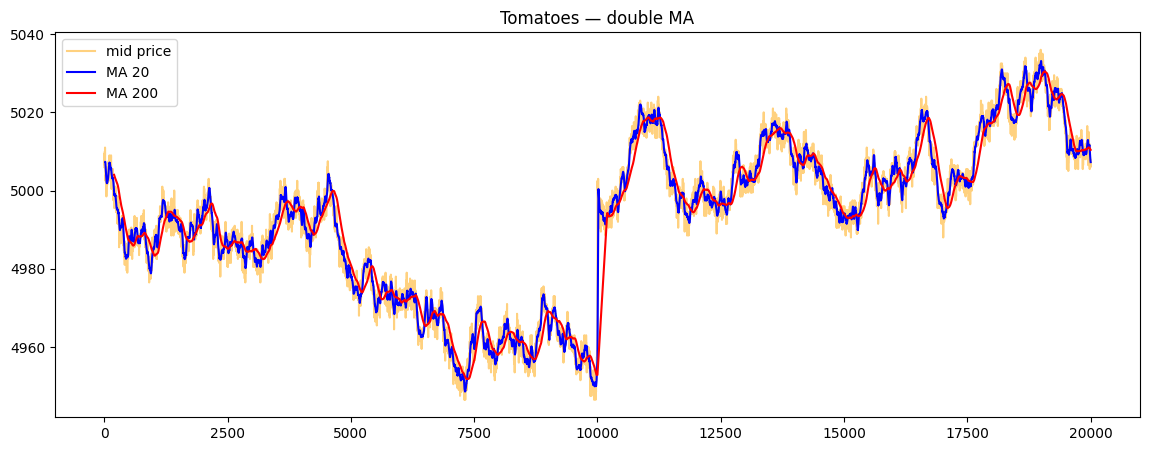

count    19801.000000
mean         0.029577
std          4.233775
min        -10.447500
25%         -2.595000
50%         -0.077500
75%          2.425000
max         43.205000
Name: signal, dtype: float64


In [4]:
tomatoes = df[df["product"] == "TOMATOES"].copy().reset_index(drop=True)
tomatoes["ma_short"] = tomatoes["mid_price"].rolling(20).mean()
tomatoes["ma_long"]  = tomatoes["mid_price"].rolling(200).mean()

plt.figure(figsize=(14, 5))
plt.plot(tomatoes["mid_price"], label="mid price", alpha=0.5, color="orange")
plt.plot(tomatoes["ma_short"],  label="MA 20",     color="blue")
plt.plot(tomatoes["ma_long"],   label="MA 200",    color="red")
plt.legend()
plt.title("Tomatoes — double MA")
plt.show()

# Signal de tendance
tomatoes["signal"] = tomatoes["ma_short"] - tomatoes["ma_long"]
print(tomatoes["signal"].describe())

In [5]:
# Visualiser quand le signal est positif vs négatif
tomatoes["signal"] = tomatoes["ma_short"] - tomatoes["ma_long"]
tomatoes["bias"] = tomatoes["signal"].apply(
    lambda x: "BUY" if x > 2 else ("SELL" if x < -2 else "NEUTRAL")
)
print(tomatoes["bias"].value_counts())

bias
NEUTRAL    8250
SELL       5970
BUY        5780
Name: count, dtype: int64
